# Network Intrusion Detection — Random Forest vs Gradient-Boosted Trees
NSL-KDD, 70/15/15 split. Binary target: `normal` vs `attack`.

This notebook continues from `NSL_KDD_EDA.ipynb` — it assumes the dataset zip is in the
same folder (Colab: upload it or mount Drive).

In [1]:
import zipfile, time, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Load data

In [2]:
zipfile.ZipFile("NSL_KDD_70_15_15_Dataset.zip").extractall("data")

CATS = ["protocol_type", "service", "flag"]

def load(path):
    d = pd.read_csv(path)
    d["binary"] = (d["label"] != "normal").astype(int)   # 1 = attack, 0 = normal
    return d

tr = load("data/KDD_train_70.csv")
va = load("data/KDD_val_15.csv")
te = load("data/KDD_test_15.csv")

# de-dup train only, as per the project's cleaning step
before = len(tr)
tr = tr.drop_duplicates().reset_index(drop=True)
print(f"train: {before} -> {len(tr)} rows after de-dup")

FEATS = [c for c in tr.columns if c not in ("label", "binary")]
NUMS  = [c for c in FEATS if c not in CATS]

Xtr, ytr = tr[FEATS], tr["binary"]
Xva, yva = va[FEATS], va["binary"]
Xte, yte = te[FEATS], te["binary"]

print("Class balance (train):", ytr.value_counts(normalize=True).round(3).to_dict())
print("Shapes:", Xtr.shape, Xva.shape, Xte.shape)

train: 103801 -> 103801 rows after de-dup
Class balance (train): {0: 0.535, 1: 0.465}
Shapes: (103801, 41) (22172, 41) (22544, 41)


## 2. Preprocessing pipeline

- `OneHotEncoder(handle_unknown="ignore")` on the 3 categorical columns — the EDA notebook
  showed `service` has categories in test that never appear in train, so unseen categories
  must be ignored rather than crash the pipeline.
- `StandardScaler` on the 38 numeric columns.
- Wrapped in a `ColumnTransformer` so the exact same fitted transform is reused for
  train / val / test / new data — no leakage, no manual re-encoding.

In [3]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATS),
    ("num", StandardScaler(), NUMS),
])

## 3. Define the two models

- **Random Forest** — bagging, trees grown independently, majority vote.
  `class_weight="balanced_subsample"` helps the rare U2R/R2L classes get represented in
  each tree's bootstrap sample.
- **Gradient-Boosted Trees** — boosting, trees grown sequentially to correct prior errors.
  `n_estimators=200, max_depth=3` is a reasonable accuracy/speed trade-off for ~100k rows;
  raise `n_estimators` or lower `learning_rate` for a further (slow) accuracy bump.

In [4]:
models = {
    "Random Forest": Pipeline([
        ("pre", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=1,
            n_jobs=-1,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
        )),
    ]),
    "Gradient Boosting": Pipeline([
        ("pre", preprocessor),
        ("clf", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=3,
            subsample=0.9,
            random_state=RANDOM_STATE,
        )),
    ]),
}

## 4. Train both models

In [5]:
fit_times = {}
for name, pipe in models.items():
    t0 = time.time()
    pipe.fit(Xtr, ytr)
    fit_times[name] = time.time() - t0
    print(f"{name:20s} trained in {fit_times[name]:.1f}s")

Random Forest        trained in 21.3s


Gradient Boosting    trained in 51.7s


## 5. Evaluate — validation AND test

Val and test are reported **separately on purpose**. Val traffic patterns resemble
training (expect ~99%+ across the board). Test contains attack types the models never
saw during training, so a real drop in test recall/accuracy is expected and is the
whole point of using NSL-KDD instead of the original KDD'99 — it stops you from fooling
yourself with an inflated score.

In [6]:
rows = []
proba_store = {}   # for ROC curves later

for name, pipe in models.items():
    for split_name, X, y in [("val", Xva, yva), ("test", Xte, yte)]:
        pred = pipe.predict(X)
        proba = pipe.predict_proba(X)[:, 1]
        if split_name == "test":
            proba_store[name] = (y, proba, pred)
        rows.append({
            "model": name, "split": split_name,
            "accuracy": accuracy_score(y, pred),
            "precision": precision_score(y, pred),
            "recall": recall_score(y, pred),
            "f1": f1_score(y, pred),
            "roc_auc": roc_auc_score(y, proba),
        })

results = pd.DataFrame(rows).set_index(["model", "split"]).round(4)
results

accuracy  precision  recall      f1  roc_auc
model             split                                              
Random Forest     val      0.9990     0.9995  0.9983  0.9989   1.0000
                  test     0.7659     0.9673  0.6094  0.7477   0.9609
Gradient Boosting val      0.9983     0.9987  0.9977  0.9982   0.9999
                  test     0.8277     0.9730  0.7171  0.8257   0.9426

### Classification report (test set) — per-class precision/recall

In [7]:
for name, pipe in models.items():
    print(f"\n=== {name} — TEST ===")
    print(classification_report(yte, pipe.predict(Xte), target_names=["normal", "attack"]))


=== Random Forest — TEST ===


              precision    recall  f1-score   support

      normal       0.65      0.97      0.78      9711
      attack       0.97      0.61      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.76     22544
weighted avg       0.83      0.77      0.76     22544


=== Gradient Boosting — TEST ===
              precision    recall  f1-score   support

      normal       0.72      0.97      0.83      9711
      attack       0.97      0.72      0.83     12833

    accuracy                           0.83     22544
   macro avg       0.85      0.85      0.83     22544
weighted avg       0.87      0.83      0.83     22544



### Confusion matrices (test set)

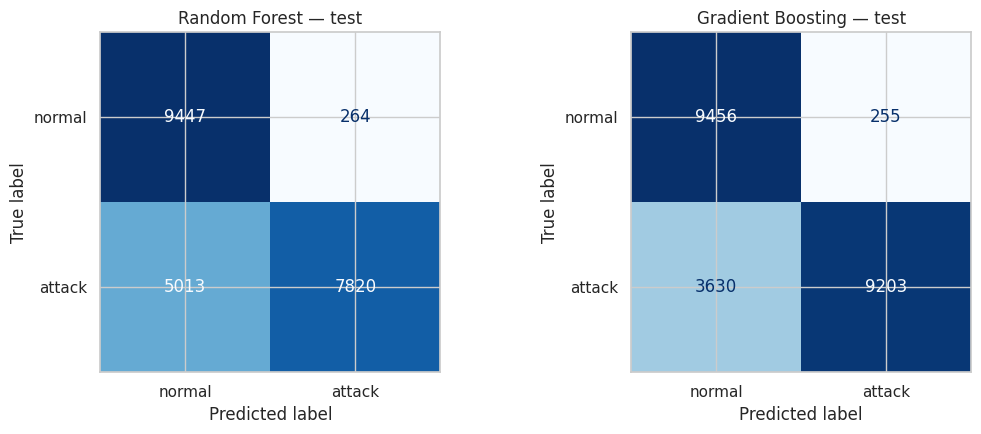

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, pipe) in zip(axes, models.items()):
    cm = confusion_matrix(yte, pipe.predict(Xte))
    ConfusionMatrixDisplay(cm, display_labels=["normal", "attack"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name} — test")
plt.tight_layout(); plt.show()

### ROC curves (test set)

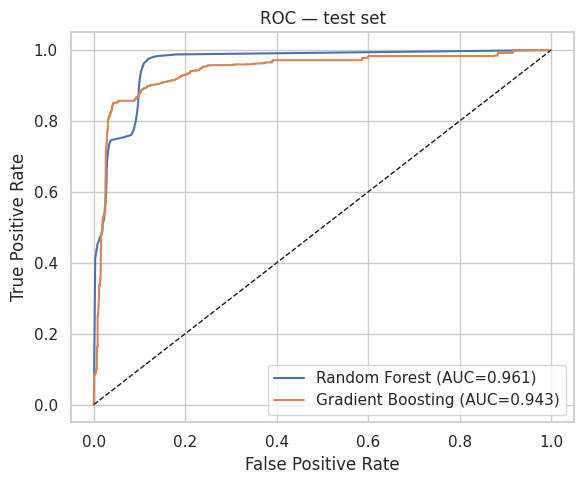

In [9]:
plt.figure(figsize=(6, 5))
for name, (y, proba, _) in proba_store.items():
    fpr, tpr, _ = roc_curve(y, proba)
    auc = roc_auc_score(y, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC — test set"); plt.legend(); plt.tight_layout(); plt.show()

### Metric comparison bar chart

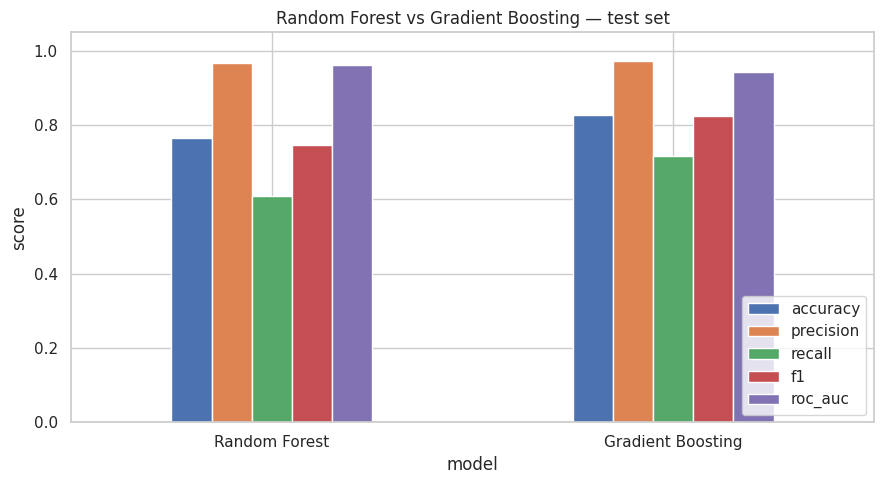

In [10]:
test_res = results.xs("test", level="split")
test_res[["accuracy", "precision", "recall", "f1", "roc_auc"]].plot(
    kind="bar", figsize=(9, 5), rot=0)
plt.title("Random Forest vs Gradient Boosting — test set")
plt.ylim(0, 1.05); plt.ylabel("score"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 6. Feature importance

Both models expose `feature_importances_` after the `OneHotEncoder` — use
`get_feature_names_out()` to map the expanded columns back to readable names.

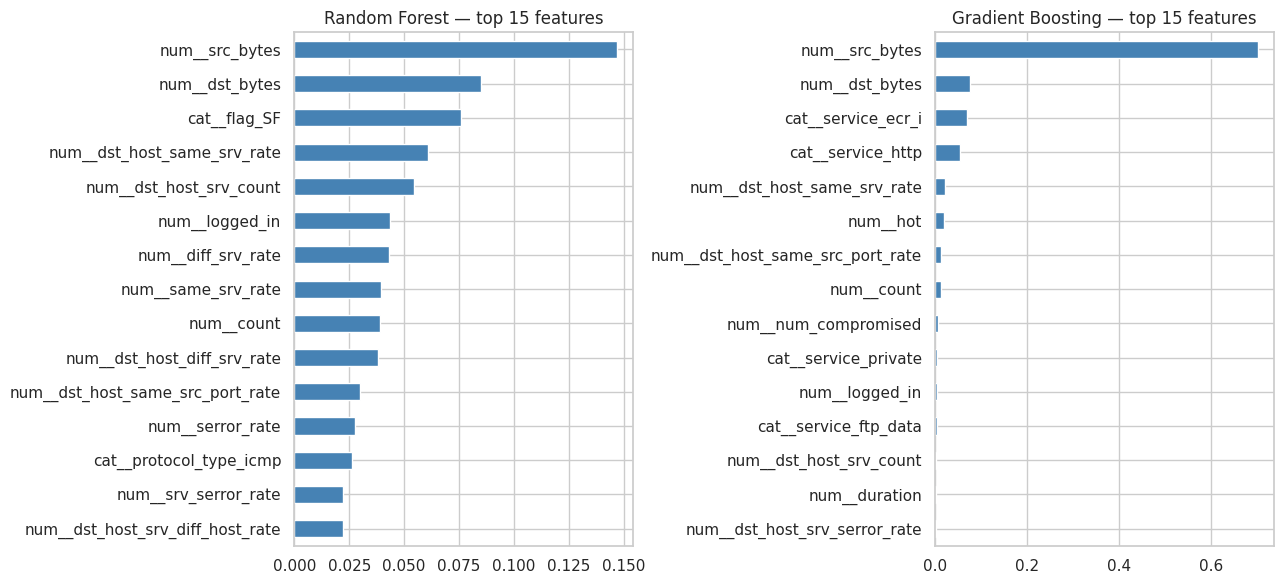

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
feat_names = models["Random Forest"].named_steps["pre"].get_feature_names_out()

for ax, (name, pipe) in zip(axes, models.items()):
    imp = pd.Series(pipe.named_steps["clf"].feature_importances_, index=feat_names)
    top = imp.sort_values(ascending=False).head(15)
    top[::-1].plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"{name} — top 15 features")
plt.tight_layout(); plt.show()

## 7. Which one wins?

Read this off the `results` table and the plots above:
- If **val is ~99% but test recall drops much more for one model**, that model is
  overfitting to attack signatures seen in training and generalizing worse to novel attacks.
- **Recall on `attack`** matters most for an IDS — a missed attack (false negative) is
  usually far costlier than a false alarm.
- Gradient Boosting typically edges out Random Forest on **precision/F1 for the rare,
  harder classes** (R2L, U2R) at the cost of longer training time; Random Forest trains
  faster and is a very strong, low-maintenance baseline.

In [12]:
print(results)

                         accuracy  precision  recall      f1  roc_auc
model             split                                              
Random Forest     val      0.9990     0.9995  0.9983  0.9989   1.0000
                  test     0.7659     0.9673  0.6094  0.7477   0.9609
Gradient Boosting val      0.9983     0.9987  0.9977  0.9982   0.9999
                  test     0.8277     0.9730  0.7171  0.8257   0.9426


## 8. Save the trained models

In [13]:
joblib.dump(models["Random Forest"], "random_forest_nsl_kdd.joblib")
joblib.dump(models["Gradient Boosting"], "gradient_boosting_nsl_kdd.joblib")
print("Saved.")

Saved.


### Optional: multi-class attack-family model
The EDA notebook already built a `family` column (`normal / dos / probe / r2l / u2r`).
Swap the target to run the same two models as a 5-class classifier — useful for a
"which attack type is being confused with which" confusion matrix in your report.

In [14]:
FAMILY = {"normal":"normal",
 "neptune":"dos","back":"dos","land":"dos","pod":"dos","smurf":"dos","teardrop":"dos",
 "mailbomb":"dos","apache2":"dos","processtable":"dos","udpstorm":"dos","worm":"dos",
 "ipsweep":"probe","nmap":"probe","portsweep":"probe","satan":"probe","mscan":"probe","saint":"probe",
 "ftp_write":"r2l","guess_passwd":"r2l","imap":"r2l","multihop":"r2l","phf":"r2l","spy":"r2l",
 "warezclient":"r2l","warezmaster":"r2l","sendmail":"r2l","named":"r2l","snmpgetattack":"r2l",
 "snmpguess":"r2l","xlock":"r2l","xsnoop":"r2l","httptunnel":"r2l",
 "buffer_overflow":"u2r","loadmodule":"u2r","perl":"u2r","rootkit":"u2r","ps":"u2r",
 "sqlattack":"u2r","xterm":"u2r"}

ytr_fam = tr["label"].map(FAMILY).fillna("unknown")
yte_fam = te["label"].map(FAMILY).fillna("unknown")

rf_fam = Pipeline([("pre", preprocessor),
                    ("clf", RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                                    class_weight="balanced_subsample",
                                                    random_state=RANDOM_STATE))])
rf_fam.fit(Xtr, ytr_fam)
print(classification_report(yte_fam, rf_fam.predict(Xte)))

              precision    recall  f1-score   support

         dos       0.96      0.77      0.85      7460
      normal       0.63      0.97      0.77      9711
       probe       0.87      0.59      0.70      2421
         r2l       0.96      0.01      0.02      2885
         u2r       0.50      0.03      0.06        67

    accuracy                           0.74     22544
   macro avg       0.78      0.47      0.48     22544
weighted avg       0.81      0.74      0.69     22544

